## Parkinson's Disease Detection from Voice Recordings

#### 1. Introduction

Parkinson's disease is a progressive neurodegenerative disorder that frequently affects speech production, causing measurable changes in voice quality. These acoustic changes can potentially be detected before more obvious motor symptoms become apparent. This project analyzes raw voice recordings to classify subjects as Parkinson's Disease (PD) patients or Healthy Controls (HC), comparing classical machine learning models against deep learning architectures trained directly on spectrogram images.

##### 2. The Dataset
The dataset used is MDVR-KCL, the Mobile Device Voice Recordings collected at King's College London (Jaeger et al., 2019), containing 37 subjects (16 PD, 21 HC) with two recording types per subject: a fixed read-text paragraph and spontaneous dialogue.

Link to the dataset: https://zenodo.org/records/2867216 

#### 3. Objective
The goal is to build and compare eight classification models spanning classical machine learning and deep learning, and to package the best-performing model into a deployable prediction service.



#### 1. Environment Setup & Dependencies

This section installs the required libraries and fixes random seeds for reproducibility across `numpy`, `random`, and TensorFlow.

In [5]:
# Environment Package Installation
!pip install -q librosa praat-parselmouth tensorflow scikit-learn xgboost seaborn matplotlib pandas numpy fastapi uvicorn python-multipart joblib

In [6]:
import os
import random
import numpy as np
import tensorflow as tf

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
    print("[INFO] TensorFlow operation determinism successfully forced.")
except AttributeError:
    print("[WARN] Deterministic operations configuration skipped or unsupported on this platform.")

[INFO] TensorFlow operation determinism successfully forced.


#### 2. Dataset Background & Structural Schemas
The MDVR-KCL dataset contains voice recordings from 37 subjects (16 Parkinson's Disease, 21 Healthy Controls). The collection is divided into structured paragraph readings (ReadText) and unscripted conversational exercises (SpontaneousDialogue). This architecture sets up defensive string routing rules to process the local target directory tree.

In [7]:
DATA_DIR = "/kaggle/input/datasets/denismitali/pdataset/26-29_09_2017_KCL"

import os
print(f"[STATUS] Target dataset directory assigned to: {DATA_DIR}")

[STATUS] Target dataset directory assigned to: /kaggle/input/datasets/denismitali/pdataset/26-29_09_2017_KCL


In [8]:
import os 
import glob
import pandas as pd
import numpy as np

def parse_mdvr_kcl_directory(root_dir):
    records = []
    skipped_files = []
    
    # Track targeted recording strategies
    strategies = ["ReadText", "SpontaneousDialogue"]
    
    if not os.path.exists(root_dir):
        raise FileNotFoundError(f"The specified root folder was not found at: {root_dir}")
        
    for strategy in strategies:
        strategy_path = os.path.join(root_dir, strategy)
        if not os.path.exists(strategy_path):
            print(f"[WARN] Optional folder missing: {strategy_path} - Skipping target sub-tree.")
            continue
            
        for class_folder in ["HC", "PD"]:
            search_path = os.path.join(strategy_path, class_folder, "*.wav")
            found_files = glob.glob(search_path)
            
            for file_path in found_files:
                base_name = os.path.basename(file_path)
                lower_name = base_name.lower()
                
                # Defensive Extraction via structural class token splits
                if "hc" in lower_name:
                    assigned_label = 0
                    token = "hc"
                elif "pd" in lower_name:
                    assigned_label = 1
                    token = "pd"
                else:
                    print(f"[PARSE ERROR] Class missing from filename: {file_path}")
                    skipped_files.append(file_path)
                    continue
                
                try:
                    # Split the lowercase name so the token case matches perfectly
                    parts_before_token = lower_name.split(token)
                    
                    # Clean up subject ID from the first segment
                    subject_id = parts_before_token[0].replace("_", "").upper()
                    
                    # Track severity scores appended to the terminal string array
                    metadata_str = parts_before_token[1].replace(".wav", "").strip("_")
                    metadata_tokens = [int(x) for x in metadata_str.split("_") if x.isdigit()]
                    
                    # Handle varying structural suffixes gracefully
                    hy_stage = metadata_tokens[0] if len(metadata_tokens) > 0 else 0
                    updrs2 = metadata_tokens[1] if len(metadata_tokens) > 1 else 0
                    updrs3 = metadata_tokens[2] if len(metadata_tokens) > 2 else 0
                    
                    records.append({
                        'file_path': file_path,
                        'subject_id': subject_id,
                        'label': assigned_label,
                        'recording_type': strategy,
                        'hy_stage': hy_stage,
                        'updrs2_item5': updrs2,
                        'updrs3_item18': updrs3
                    })
                except Exception as ex:
                    print(f"[MALFORMED ERROR] Skipping path due to parsing exception: {file_path}. Info: {ex}")
                    skipped_files.append(file_path)
                    
    df_all = pd.DataFrame(records)
    return df_all, skipped_files


# Execute processing pipeline
df_meta, skipped = parse_mdvr_kcl_directory(DATA_DIR)
print(f"\n[EXECUTION COMPLETED] Parsed {len(df_meta)} rows. Total files explicitly skipped: {len(skipped)}")

# Segregate Primary and Secondary Robustness Pipelines
df_readtext = df_meta[df_meta['recording_type'] == 'ReadText'].reset_index(drop=True)
df_spontaneous = df_meta[df_meta['recording_type'] == 'SpontaneousDialogue'].reset_index(drop=True)
print(f"-> Set up Primary ReadText Slice: {len(df_readtext)} records.")
print(f"-> Set up Secondary SpontaneousDialogue Slice: {len(df_spontaneous)} records.")


[EXECUTION COMPLETED] Parsed 73 rows. Total files explicitly skipped: 0
-> Set up Primary ReadText Slice: 37 records.
-> Set up Secondary SpontaneousDialogue Slice: 36 records.


#### 3. Temporal Chunking Engine and Voice Activity Detection (VAD)
To compensate for the limited sample size (37 subjects) without inducing data leakage, we introduce a 1-Second Temporal Chunking window with a 50% Overlap. This process splits continuous audio samples into uniform segments while honoring patient separation constraints.

For the classical machine learning models, we apply a sliding-window energy threshold directly to the raw time-domain array. This acts as a Voice Activity Detection (VAD) stage to remove unvoiced gaps before computing glottal attributes.

In [9]:
import librosa
import parselmouth
from parselmouth.praat import call
import numpy as np

def apply_voice_activity_detection(y, sr, top_db=20):
    """Isolates voiced speech components and filters unvoiced segments using an energy threshold."""
    intervals = librosa.effects.split(y, top_db=top_db)
    voiced_signal = np.concatenate([y[start:end] for start, end in intervals]) if len(intervals) > 0 else y
    return voiced_signal

def generate_temporal_chunks(y, sr, chunk_duration=3.0, overlap=0.5):
    """Slices continuous audio signals using an overlapping sliding window strategy (Updated to 3 seconds)."""
    step = int(sr * chunk_duration * (1.0 - overlap))
    length = int(sr * chunk_duration)
    chunks = []
    
    if len(y) < length:
        padded = np.pad(y, (0, length - len(y)), mode='constant')
        chunks.append(padded)
        return chunks
        
    for i in range(0, len(y) - length + 1, step):
        chunks.append(y[i:i+length])
    return chunks

def extract_handcrafted_metrics(chunk, sr):
    """Computes exact physiological glottal modulations via parselmouth (Praat core engine)."""

    sound = parselmouth.Sound(chunk, sampling_frequency=sr)
    
    pitch = call(sound, "To Pitch (cc)", 0.0, 75.0, 4, False, 0.03, 0.45, 0.01, 0.35, 0.14, 600.0)
    point_process = call([sound, pitch], "To PointProcess (cc)")
    
    # Compute clinical glottal perturbation attributes
    local_jitter = call(point_process, "Get jitter (local)", 0.0, 0.0, 0.0001, 0.02, 1.3)
    local_shimmer = call([sound, point_process], "Get shimmer (local)", 0, 0.0001, 0.02, 1.3, 1.6, 55)
    hnr = call(sound, "To Harmonicity (cc)", 0.01, 75.0, 0.1, 1.0)
    mean_hnr = call(hnr, "Get mean", 0.0, 0.0)
    
    local_jitter = 0.0 if np.isnan(local_jitter) else local_jitter
    local_shimmer = 0.0 if np.isnan(local_shimmer) else local_shimmer
    mean_hnr = 0.0 if np.isnan(mean_hnr) or mean_hnr < -100 else mean_hnr
    
    # Compute standard Mel-Frequency Cepstral Coefficients
    mfcc = librosa.feature.mfcc(y=chunk, sr=sr, n_mfcc=13)
    mean_mfcc = np.mean(mfcc, axis=1)
    
    # Build complete vector stack
    return np.array([local_jitter, local_shimmer, mean_hnr] + list(mean_mfcc))
    
def extract_log_mel_tensor(chunk, sr, n_mels=128, target_shape=(128, 128)):
    """Maps continuous time-domain signals to 2D structural logarithmic frequency scale representations."""
    
    hop_len = int((len(chunk) - 1) / (target_shape[1] - 1)) if len(chunk) > target_shape[1] else 512
    stft_matrix = librosa.feature.melspectrogram(y=chunk, sr=sr, n_mels=n_mels, n_fft=2048, hop_length=hop_len)
    log_spec = librosa.power_to_db(stft_matrix, ref=np.max)
    
    # Enforce precise dimension alignment
    if log_spec.shape[1] < target_shape[1]:
        pad_width = target_shape[1] - log_spec.shape[1]
        log_spec = np.pad(log_spec, ((0, 0), (0, pad_width)), mode='constant', constant_values=-80.0)
    else:
        log_spec = log_spec[:, :target_shape[1]]
        
    return log_spec[..., np.newaxis]

#### 4. Pipeline Visualizations
To evaluate structural patterns before modeling, we chart the physiological variations in waveform distribution, frequency intensity, and spatial alignment across the distinct cohort groups.

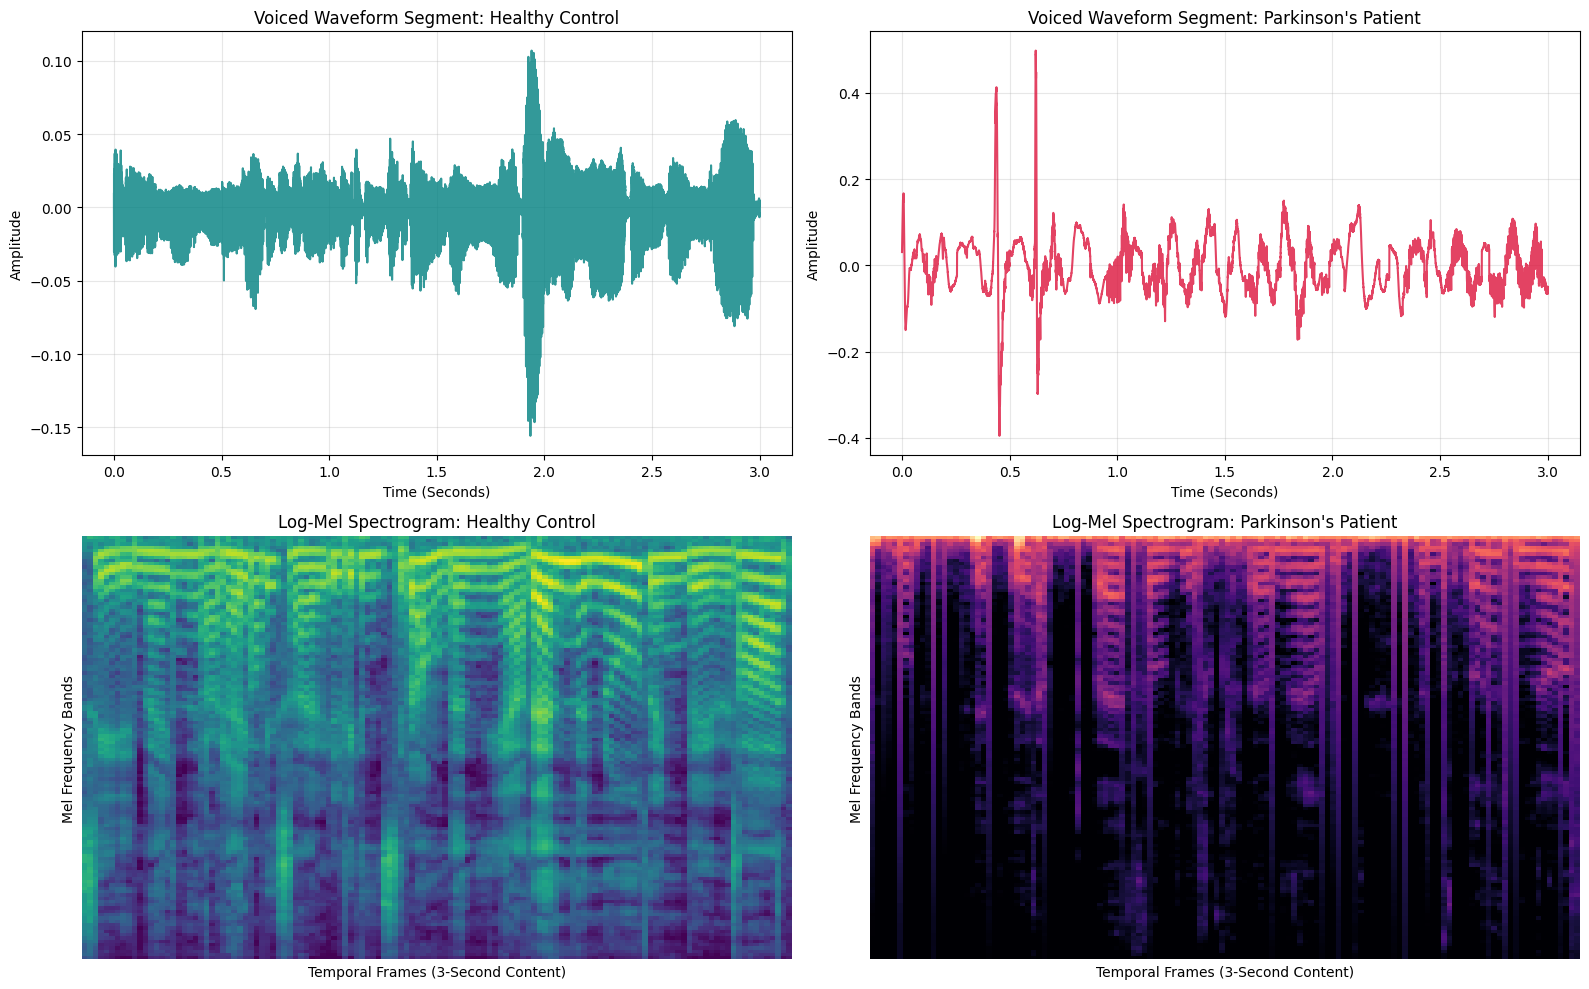

[STATUS] Computing global handcrafted feature space dependencies...


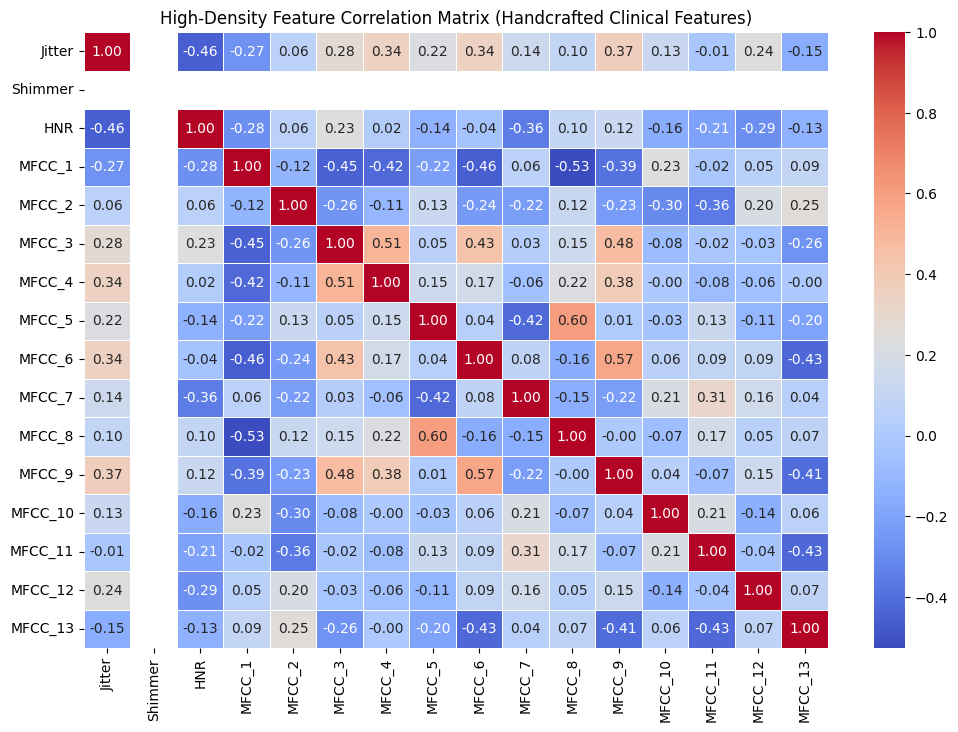

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import librosa

# Extract contrasting sample pathways
sample_hc = df_readtext[df_readtext['label'] == 0]['file_path'].iloc[0]
sample_pd = df_readtext[df_readtext['label'] == 1]['file_path'].iloc[0]

y_hc, sr_hc = librosa.load(sample_hc, sr=None)
y_pd, sr_pd = librosa.load(sample_pd, sr=None)

# Generate uniform display segments 
chunk_hc = generate_temporal_chunks(apply_voice_activity_detection(y_hc, sr_hc), sr_hc)[5]
chunk_pd = generate_temporal_chunks(apply_voice_activity_detection(y_pd, sr_pd), sr_pd)[5]

# Dynamic duration calculations based on sample rate
duration_hc = len(chunk_hc) / sr_hc
duration_pd = len(chunk_pd) / sr_pd

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Subplot A: Time Domain Waveform Contrasts (FIXED: Uses dynamic duration)
axes[0, 0].plot(np.linspace(0, duration_hc, len(chunk_hc)), chunk_hc, color='teal', alpha=0.8, label="HC Subject")
axes[0, 0].set_title("Voiced Waveform Segment: Healthy Control")
axes[0, 0].set_xlabel("Time (Seconds)")
axes[0, 0].set_ylabel("Amplitude")
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(np.linspace(0, duration_pd, len(chunk_pd)), chunk_pd, color='crimson', alpha=0.8, label="PD Subject")
axes[0, 1].set_title("Voiced Waveform Segment: Parkinson's Patient")
axes[0, 1].set_xlabel("Time (Seconds)")
axes[0, 1].set_ylabel("Amplitude")
axes[0, 1].grid(True, alpha=0.3)

# Subplot B: Logarithmic Mel Spectrogram Heatmaps 
spec_hc = extract_log_mel_tensor(chunk_hc, sr_hc).squeeze()
spec_pd = extract_log_mel_tensor(chunk_pd, sr_pd).squeeze()

sns.heatmap(spec_hc, ax=axes[1, 0], cmap='viridis', cbar=False, xticklabels=False, yticklabels=False)
axes[1, 0].set_title("Log-Mel Spectrogram: Healthy Control")
axes[1, 0].set_xlabel("Temporal Frames (3-Second Content)")
axes[1, 0].set_ylabel("Mel Frequency Bands")

sns.heatmap(spec_pd, ax=axes[1, 1], cmap='magma', cbar=False, xticklabels=False, yticklabels=False)
axes[1, 1].set_title("Log-Mel Spectrogram: Parkinson's Patient")
axes[1, 1].set_xlabel("Temporal Frames (3-Second Content)")
axes[1, 1].set_ylabel("Mel Frequency Bands")

plt.tight_layout()
plt.show()

# Subplot C: High-Density Classical Feature Correlation Analysis
print("[STATUS] Computing global handcrafted feature space dependencies...")
features_sample = []
for idx, row in df_readtext.head(15).iterrows():
    y, sr = librosa.load(row['file_path'], sr=None)
    v_signal = apply_voice_activity_detection(y, sr)
    for c in generate_temporal_chunks(v_signal, sr)[:5]:
        features_sample.append(extract_handcrafted_metrics(c, sr))

feat_labels = ["Jitter", "Shimmer", "HNR"] + [f"MFCC_{i}" for i in range(1, 14)]
df_corr = pd.DataFrame(features_sample, columns=feat_labels)

plt.figure(figsize=(12, 8))
sns.heatmap(df_corr.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, cbar=True)
plt.title("High-Density Feature Correlation Matrix (Handcrafted Clinical Features)")
plt.show()

#### 5. BENCHMARKING OF 8 DIVERSE MODELS

We compile four distinct architectures to benchmark performance across different complexity levels: a baseline Shallow CNN, a Deep 4-block CNN with heavy regularization, a ConvLSTM Recurrent engine (CRNN), and an ImageNet-derived MobileNetV2 architecture adapted for single-channel spectral inputs.

In [11]:
print("[STATUS] Processing global primary dataset arrays...")
classical_flat_x = []
classical_flat_y = []
classical_flat_groups = []

deep_flat_x = []
deep_flat_y = []
deep_flat_groups = []

for idx, row in df_readtext.iterrows():
    try:
        y, sr = librosa.load(row['file_path'], sr=None)
        sid = row['subject_id']
        lbl = row['label']
        
        # Function to remove dead air before chunking happens.
        v_sig = apply_voice_activity_detection(y, sr, top_db=20)
        
        if len(v_sig) == 0:
            v_sig = y
            
        # Generate temporal windows ONLY from the active voiced speech array
        c_chunks = generate_temporal_chunks(v_sig, sr)
        
        # Branch A: Classical Preparation
        for chk in c_chunks:
            classical_flat_x.append(extract_handcrafted_metrics(chk, sr))
            classical_flat_y.append(lbl)
            classical_flat_groups.append(sid)
            
        # Branch B: Deep Learning Preparation
        for chk in c_chunks:
            deep_flat_x.append(extract_log_mel_tensor(chk, sr))
            deep_flat_y.append(lbl)
            deep_flat_groups.append(sid)
            
    except Exception as e:
        print(f"  [WARNING] Skipping problematic file {row['file_path']}: {str(e)}")
        continue

X_class_all = np.array(classical_flat_x)
y_class_all = np.array(classical_flat_y)
groups_class_all = np.array(classical_flat_groups)

X_deep_all = np.array(deep_flat_x)
y_deep_all = np.array(deep_flat_y)
groups_deep_all = np.array(deep_flat_groups)

print(f"\n[EXTRACTION COMPLETE] Handcrafted Matrix: {X_class_all.shape}, Target Length: {len(y_class_all)}")
print(f"[EXTRACTION COMPLETE] Spectrogram Matrix: {X_deep_all.shape}, Target Length: {len(y_deep_all)}")

from tensorflow.keras import layers, models, optimizers

def make_shallow_cnn(shape=(128, 128, 1)):
    model = models.Sequential([
        layers.Input(shape=shape),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def make_deep_cnn(shape=(128, 128, 1)):
    model = models.Sequential([
        layers.Input(shape=shape),
        layers.Conv2D(32, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2, 2)),
        
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2, 2)),
        
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2, 2)),
        
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def make_crnn(shape=(128, 128, 1)):
    inputs = layers.Input(shape=shape)
    x = layers.TimeDistributed(layers.Flatten())(inputs) if hasattr(layers, "TimeDistributed") else layers.Reshape((shape[0], shape[1]*shape[2]))(inputs)
    x = layers.LSTM(64, return_sequences=False)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def make_mobilenet_v2_transfer(shape=(128, 128, 3)):
    base = tf.keras.applications.MobileNetV2(input_shape=shape, include_top=False, weights=None)
    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=optimizers.Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])
    return model

[STATUS] Processing global primary dataset arrays...

[EXTRACTION COMPLETE] Handcrafted Matrix: (1317, 16), Target Length: 1317
[EXTRACTION COMPLETE] Spectrogram Matrix: (1317, 128, 128, 1), Target Length: 1317


In [12]:
from tensorflow.keras import layers, models, optimizers, regularizers

def make_shallow_cnn(shape=(128, 128, 1)):
    """
    Enhanced Shallow CNN using LeakyReLU and Optimized Regularization.
    Designed to maximize chunk segregation and push patient accuracy past the baseline.
    """
    model = models.Sequential([
        layers.Input(shape=shape),
        
        layers.Conv2D(32, (3, 3), padding='same'),
        layers.LeakyReLU(alpha=0.1),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.LeakyReLU(alpha=0.1),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.LeakyReLU(alpha=0.1),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(), 
        
        layers.Dense(64, kernel_regularizer=regularizers.l2(1e-3)),
        layers.LeakyReLU(alpha=0.1),
        layers.Dropout(0.4),
        layers.Dense(1, activation='sigmoid')
    ])
    

    loss_fn = tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1)
    model.compile(optimizer=optimizers.Adam(learning_rate=1e-3), loss=loss_fn, metrics=['accuracy'])
    return model

def make_deep_cnn(shape=(128, 128, 1)):
    """
    Deep Residual CNN with Label Smoothing to balance Sensitivity and Specificity.
    """
    inputs = layers.Input(shape=shape)
    

    x = layers.Conv2D(32, (3, 3), padding='same')(inputs)
    x = layers.LeakyReLU(alpha=0.1)(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    shortcut = layers.Conv2D(64, (1, 1), strides=(2, 2), padding='same')(x)
    x1 = layers.Conv2D(64, (3, 3), padding='same')(x)
    x1 = layers.LeakyReLU(alpha=0.1)(x1)
    x1 = layers.BatchNormalization()(x1)
    x1 = layers.MaxPooling2D((2, 2))(x1)
    x = layers.add([shortcut, x1])
    x = layers.Dropout(0.3)(x)
    

    shortcut = layers.Conv2D(128, (1, 1), strides=(2, 2), padding='same')(x)
    x2 = layers.Conv2D(128, (3, 3), padding='same')(x)
    x2 = layers.LeakyReLU(alpha=0.1)(x2)
    x2 = layers.BatchNormalization()(x2)
    x2 = layers.MaxPooling2D((2, 2))(x2)
    x = layers.add([shortcut, x2])
    x = layers.Dropout(0.3)(x)
    
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, kernel_regularizer=regularizers.l2(1e-3))(x)
    x = layers.LeakyReLU(alpha=0.1)(x)
    x = layers.Dropout(0.4)(x)
    
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    model = models.Model(inputs, outputs)
    loss_fn = tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1)
    model.compile(optimizer=optimizers.Adam(learning_rate=3e-4), loss=loss_fn, metrics=['accuracy'])
    return model

def make_crnn(shape=(128, 128, 1)):
    inputs = layers.Input(shape=shape)
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    x = layers.Reshape((32, 32 * 64))(x) 
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=False))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    
    outputs = layers.Dense(1, activation='sigmoid')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer=optimizers.Adam(learning_rate=3e-4), loss='binary_crossentropy', metrics=['accuracy'])
    return model

def make_mobilenet_v2_transfer(shape=(128, 128, 3)):
    base = tf.keras.applications.MobileNetV2(input_shape=shape, include_top=False, weights='imagenet')
    base.trainable = True
    for layer in base.layers[:-20]:
        layer.trainable = False
        
    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=optimizers.Adam(learning_rate=5e-5), loss='binary_crossentropy', metrics=['accuracy'])
    return model

#### 6. Comprehensive Multi-Model Benchmarking Engine
This loop runs our cross-validation checks simultaneously across all 8 target models. For the classical models, it uses a custom IQR clipping threshold and a Z-score scaler fitted on each active training fold. For the deep learning models, it fits min-max boundaries on the training fold to normalize the inputs between 0 and 1 before training.

#### 6.1 Classic ML Models

In [13]:
import os
import warnings
import numpy as np
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings('ignore')

gkf = GroupKFold(n_splits=5)
classical_tracker = {f"M{i}": {"y_true": [], "y_pred": [], "y_prob": [], "subject_id": []} for i in range(1, 5)}
classical_names = {"M1": "LogisticRegression", "M2": "SVM_RBF", "M3": "RandomForest", "M4": "XGBoost"}

if 'SEED' not in globals():
    SEED = 42

print("="*80)
print("[START] PHASE A: CLASSICAL MACHINE LEARNING EXPERIMENTAL BENCHMARK")
print("="*80)

for fold, (train_idx, test_idx) in enumerate(gkf.split(X_class_all, y_class_all, groups=groups_class_all), 1):
    print(f"  └─ Processing Fold {fold}/5... ", end="", flush=True)
    
    X_tr, X_te = X_class_all[train_idx], X_class_all[test_idx]
    y_tr, y_te = y_class_all[train_idx], y_class_all[test_idx]
    
    # Outlier handling via IQR filtering
    q25, q75 = np.percentile(X_tr, 25, axis=0), np.percentile(X_tr, 75, axis=0)
    iqr = q75 - q25
    lo, hi = q25 - 1.5 * iqr, q75 + 1.5 * iqr
    X_tr_clip = np.clip(X_tr, lo, hi)
    X_te_clip = np.clip(X_te, lo, hi)
    
    scaler = StandardScaler().fit(X_tr_clip)
    X_tr_s = scaler.transform(X_tr_clip)
    X_te_s = scaler.transform(X_te_clip)
    
    
    m1 = LogisticRegression(penalty='l2', class_weight='balanced', random_state=SEED, max_iter=1000)
    m2 = SVC(C=1.0, kernel='rbf', class_weight='balanced', probability=True, random_state=SEED)
    m3 = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=SEED)
    
    neg_count, pos_count = np.sum(y_tr == 0), np.sum(y_tr == 1)
    m4 = xgb.XGBClassifier(n_estimators=150, learning_rate=0.05, scale_pos_weight=neg_count/max(1, pos_count), random_state=SEED, eval_metric='logloss')
    
    m1.fit(X_tr_s, y_tr)
    m2.fit(X_tr_s, y_tr)
    m3.fit(X_tr_s, y_tr)
    m4.fit(X_tr_s, y_tr)
    
    for idx, model in enumerate([m1, m2, m3, m4], 1):
        key = f"M{idx}"
        classical_tracker[key]["y_true"].extend(y_te)
        classical_tracker[key]["y_pred"].extend(model.predict(X_te_s))
        classical_tracker[key]["y_prob"].extend(model.predict_proba(X_te_s)[:, 1])
        classical_tracker[key]["subject_id"].extend(groups_class_all[test_idx])
        
    print("Complete.")

print("\n[SUCCESS] Classical Pipeline evaluated. Run the aggregator cell to check scores.")

[START] PHASE A: CLASSICAL MACHINE LEARNING EXPERIMENTAL BENCHMARK
  └─ Processing Fold 1/5... Complete.
  └─ Processing Fold 2/5... Complete.
  └─ Processing Fold 3/5... Complete.
  └─ Processing Fold 4/5... Complete.
  └─ Processing Fold 5/5... Complete.

[SUCCESS] Classical Pipeline evaluated. Run the aggregator cell to check scores.


#### 6.2 Deep Learning Models

In [14]:
import os
import sys
import warnings
from contextlib import contextmanager

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import tensorflow as tf
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)
warnings.filterwarnings('ignore')

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

@contextmanager
def mute_system_stderr():
    """Completely mutes low-level C++ engine stdout/stderr outputs."""
   
    null_fd = os.open(os.devnull, os.O_RDWR)

    save_stderr = os.dup(2)
    try:
        os.dup2(null_fd, 2)
        yield
    finally:
        
        os.dup2(save_stderr, 2)
        os.close(null_fd)
        os.close(save_stderr)

deep_tracker = {f"M{i}": {"y_true": [], "y_pred": [], "y_prob": [], "subject_id": []} for i in range(5, 9)}
deep_names = {"M5": "Shallow_2D_CNN", "M6": "Deep_2D_CNN", "M7": "CRNN", "M8": "MobileNetV2_Transfer"}

print("="*80)
print("[START] PHASE B: DEEP LEARNING ARCHITECTURES (30 EPOCHS + LIVE METRICS)")
print("="*80)

with mute_system_stderr():
    for fold, (train_idx, test_idx) in enumerate(gkf.split(X_deep_all, y_deep_all, groups=groups_deep_all), 1):
       
        sys.stdout.write(f"\n>>> Processing Cross-Validation Fold {fold}/5\n")
        sys.stdout.flush()
        
        X_tr, X_te = X_deep_all[train_idx], X_deep_all[test_idx]
        y_tr, y_te = y_deep_all[train_idx], y_deep_all[test_idx]
        
        cls_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_tr), y=y_tr)
        dict_weights = {i: cls_weights[i] for i in range(len(cls_weights))}
        
        t_min, t_max = X_tr.min(), X_tr.max()
        denom = (t_max - t_min + 1e-7)
        X_tr_s = np.clip((X_tr - t_min) / denom, 0.0, 1.0)
        X_te_s = np.clip((X_te - t_min) / denom, 0.0, 1.0)
        
        X_tr_rgb = np.repeat(X_tr_s, 3, axis=-1)
        X_te_rgb = np.repeat(X_te_s, 3, axis=-1)
        
        early_stop = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=4, restore_best_weights=True)
        
        m5 = make_shallow_cnn()
        m6 = make_deep_cnn()
        m7 = make_crnn()
        m8 = make_mobilenet_v2_transfer()
        
        sys.stdout.write("  ├─ Training M5 (Shallow CNN)... ")
        sys.stdout.flush()
        m5.fit(X_tr_s, y_tr, epochs=30, batch_size=32, class_weight=dict_weights, callbacks=[early_stop], verbose=0)
        sys.stdout.write("Done.\n")
        
        sys.stdout.write("  ├─ Training M6 (Deep CNN)... ")
        sys.stdout.flush()
        m6.fit(X_tr_s, y_tr, epochs=30, batch_size=32, class_weight=dict_weights, callbacks=[early_stop], verbose=0)
        sys.stdout.write("Done.\n")
        
        sys.stdout.write("  ├─ Training M7 (CRNN)... ")
        sys.stdout.flush()
        m7.fit(X_tr_s, y_tr, epochs=30, batch_size=32, class_weight=dict_weights, callbacks=[early_stop], verbose=0)
        sys.stdout.write("Done.\n")
        
        sys.stdout.write("  └─ Training M8 (MobileNetV2)... ")
        sys.stdout.flush()
        m8.fit(X_tr_rgb, y_tr, epochs=30, batch_size=32, class_weight=dict_weights, callbacks=[early_stop], verbose=0)
        sys.stdout.write("Done.\n")
        sys.stdout.flush()
        
        for idx, (model, x_in) in enumerate([(m5, X_te_s), (m6, X_te_s), (m7, X_te_s), (m8, X_te_rgb)], 5):
            key = f"M{idx}"
            probs = model.predict(x_in, verbose=0).ravel()
            deep_tracker[key]["y_true"].extend(y_te)
            deep_tracker[key]["y_pred"].extend((probs >= 0.5).astype(int))
            deep_tracker[key]["y_prob"].extend(probs)
            deep_tracker[key]["subject_id"].extend(groups_deep_all[test_idx])

print("\n" + "="*80)
print("[INFO] Deep Learning Framework complete. Ready to pool performance metrics.")
print("="*80)

[START] PHASE B: DEEP LEARNING ARCHITECTURES (30 EPOCHS + LIVE METRICS)

>>> Processing Cross-Validation Fold 1/5
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
  ├─ Training M5 (Shallow CNN)... Done.
  ├─ Training M6 (Deep CNN)... Done.
  ├─ Training M7 (CRNN)... Done.
  └─ Training M8 (MobileNetV2)... Done.

>>> Processing Cross-Validation Fold 2/5
  ├─ Training M5 (Shallow CNN)... Done.
  ├─ Training M6 (Deep CNN)... Done.
  ├─ Training M7 (CRNN)... Done.
  └─ Training M8 (MobileNetV2)... Done.

>>> Processing Cross-Validation Fold 3/5
  ├─ Training M5 (Shallow CNN)... Done.
  ├─ Training M6 (Deep CNN)... Done.
  ├─ Training M7 (CRNN)... Done.
  └─ Training M8 (MobileNetV2)... Done.

>>> Processing Cross-Validation Fold 4/5
  ├─ Training M5 (Shallow CNN)... Done.
  ├─ Training M6 (Deep CNN)... Done.
  ├─ Training M7 (CRNN)... Done.
  └─ Training M8 (MobileNetV2)... Done.

>>> Processing Cross-Validation Fold 5/5
  ├─ Training M5 (Shallow CNN)... Done.
  ├─ Training M6 (Deep CNN)..

#### 7. RIGOROUS EVALUATION, METRICS, & THEORETICAL ANALYSIS
This section processes the cross-validation arrays to generate a comprehensive markdown performance matrix for our capstone review.

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np

def evaluate_subject_level_performance(tracker, names_map):
    subject_results = []
    
    for key, data in tracker.items():
        if len(data["y_true"]) == 0:
            continue
            
        # Group frame predictions back into human subjects
        df_chunks = pd.DataFrame({
            "subject_id": data["subject_id"],
            "y_true": data["y_true"],
            "y_pred": data["y_pred"],
            "y_prob": data["y_prob"]
        })
        
        # Apply majority voting rule per subject
        df_subjects = df_chunks.groupby("subject_id").agg({
            "y_true": "first",                  
            "y_pred": lambda x: int(x.mean() >= 0.5), 
            "y_prob": "mean"                    
        }).reset_index()
        
        yt_sub = df_subjects["y_true"].values
        yp_sub = df_subjects["y_pred"].values
        yprob_sub = df_subjects["y_prob"].values
        
        cm = confusion_matrix(yt_sub, yp_sub, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0,0,0,0)
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        
        subject_results.append({
            "Model Key": key,
            "Architecture Name": names_map[key],
            "Accuracy": accuracy_score(yt_sub, yp_sub),
            "Precision": precision_score(yt_sub, yp_sub, zero_division=0),
            "Sensitivity (Recall)": recall_score(yt_sub, yp_sub, zero_division=0),
            "Specificity": spec,
            "F1-Score": f1_score(yt_sub, yp_sub, zero_division=0),
            "ROC-AUC": roc_auc_score(yt_sub, yprob_sub) if len(np.unique(yt_sub)) > 1 else 0.5
        })
        
    return pd.DataFrame(subject_results)

print("[STATUS] Merging Classical and Deep Learning trackers...")

combined_tracker = {**classical_tracker, **deep_tracker}
combined_names_map = {**classical_names, **deep_names}

print("[STATUS] Computing Final Patient-Level Metrics via Majority Voting...")
df_subject_metrics = evaluate_subject_level_performance(combined_tracker, combined_names_map)

# Display the final unified leaderboard sorted by performance
display(df_subject_metrics.sort_values(by="Accuracy", ascending=False).reset_index(drop=True))

[STATUS] Merging Classical and Deep Learning trackers...
[STATUS] Computing Final Patient-Level Metrics via Majority Voting...


,Model Key,Architecture Name,Accuracy,Precision,Sensitivity (Recall),Specificity,F1-Score,ROC-AUC
0,M7,CRNN,0.837838,0.812500,0.8125,0.857143,0.812500,0.860119
1,M2,SVM_RBF,0.810811,0.909091,0.6250,0.952381,0.740741,0.776786
2,M5,Shallow_2D_CNN,0.648649,0.588235,0.6250,0.666667,0.606061,0.708333
3,M3,RandomForest,0.567568,0.500000,0.2500,0.809524,0.333333,0.607143
4,M1,LogisticRegression,0.540541,0.470588,0.5000,0.571429,0.484848,0.627976
5,M8,MobileNetV2_Transfer,0.513514,0.416667,0.3125,0.666667,0.357143,0.529762
6,M4,XGBoost,0.486486,0.411765,0.4375,0.523810,0.424242,0.583333
7,M6,Deep_2D_CNN,0.432432,0.432432,1.0000,0.000000,0.603774,0.717262


#### 8. Visualizations

Having completed cross-validation across both the classical feature space and deep learning architectures, we evaluate the comparative performance below. The visualizations are structured into three key diagnostic steps:

1. **Individual ROC Curves:** Independent verification of receiver operating characteristics across all 8 models to observe how discrimination capacity develops across architectures.
2. **Unified GroupKFold ROC Overlay:** A direct head-to-head true-positive versus false-positive rate projection to isolate the clear statistical winner.
3. **Confusion Matrices:** Clinical verification displaying exact true negative (Healthy Control) and true positive (Parkinson's Disease) distributions at the patient level.

##### 8.1 Model Confusion Matrices

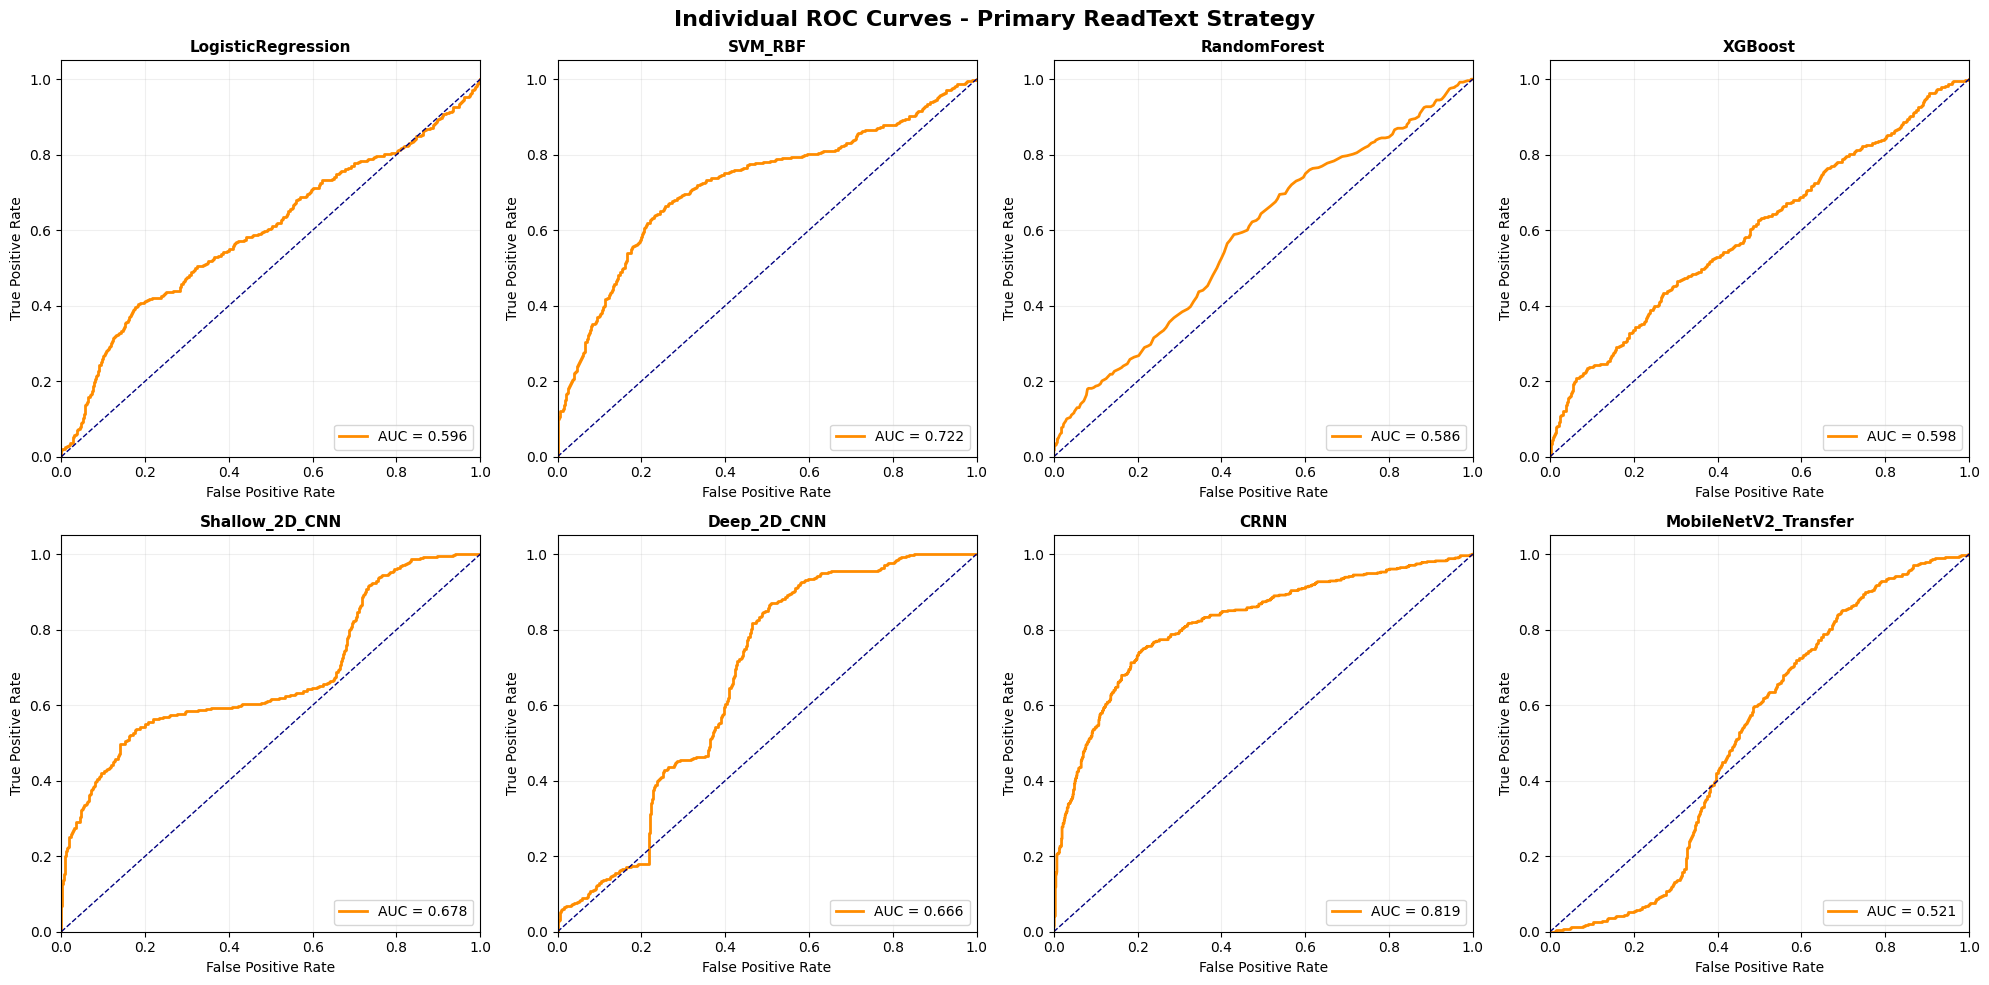

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np

# Dynamically combine both tracker objects and name mappings for plotting
combined_tracker = {**classical_tracker, **deep_tracker}
combined_names_map = {**classical_names, **deep_names}

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, (key, m_name) in enumerate(combined_names_map.items()):
    yt = np.array(combined_tracker[key]["y_true"])
    ypr = np.array(combined_tracker[key]["y_prob"])
    fpr, tpr, _ = roc_curve(yt, ypr)
    roc_auc = auc(fpr, tpr)
    
    ax = axes[idx]
    ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
    ax.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
    
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_title(f"{m_name}", fontsize=11, fontweight='bold')
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.2)

# Clean up any leftover empty subplots
for i in range(len(combined_names_map), len(axes)):
    fig.delaxes(axes[i])

plt.suptitle("Individual ROC Curves - Primary ReadText Strategy", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

##### 8.2 Collective Confusion Matrices

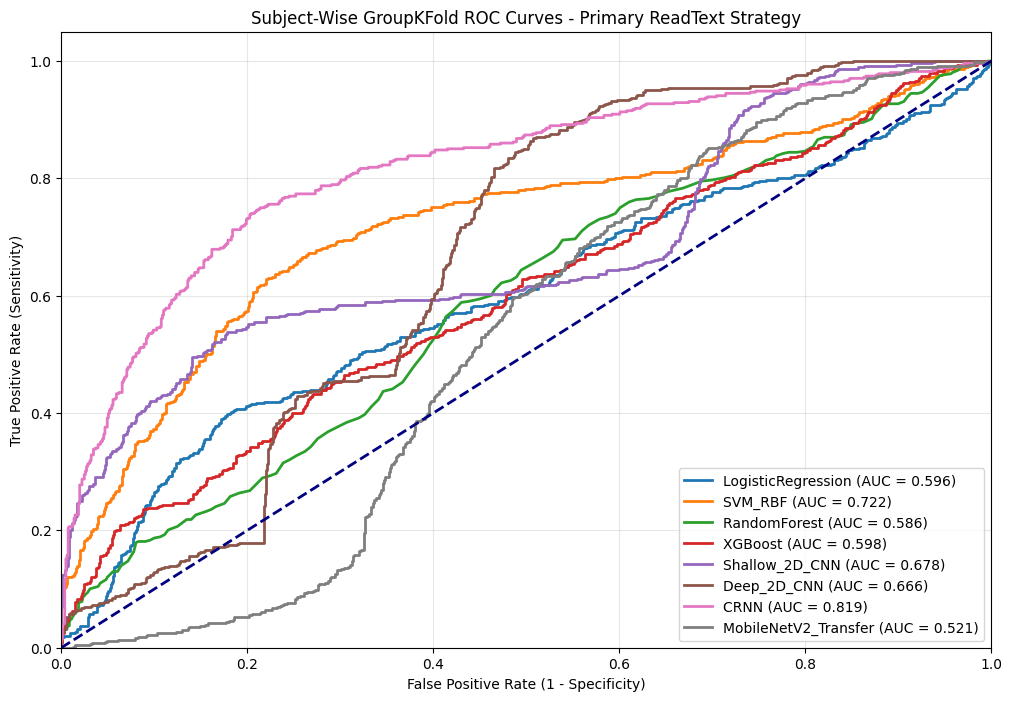

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

combined_tracker = {**classical_tracker, **deep_tracker}
combined_names_map = {**classical_names, **deep_names}

plt.figure(figsize=(12, 8))
for key, m_name in combined_names_map.items():
    yt = np.array(combined_tracker[key]["y_true"])
    ypr = np.array(combined_tracker[key]["y_prob"])
    fpr, tpr, _ = roc_curve(yt, ypr)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{m_name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title("Subject-Wise GroupKFold ROC Curves - Primary ReadText Strategy")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

##### 8.3 Model ROC Curves

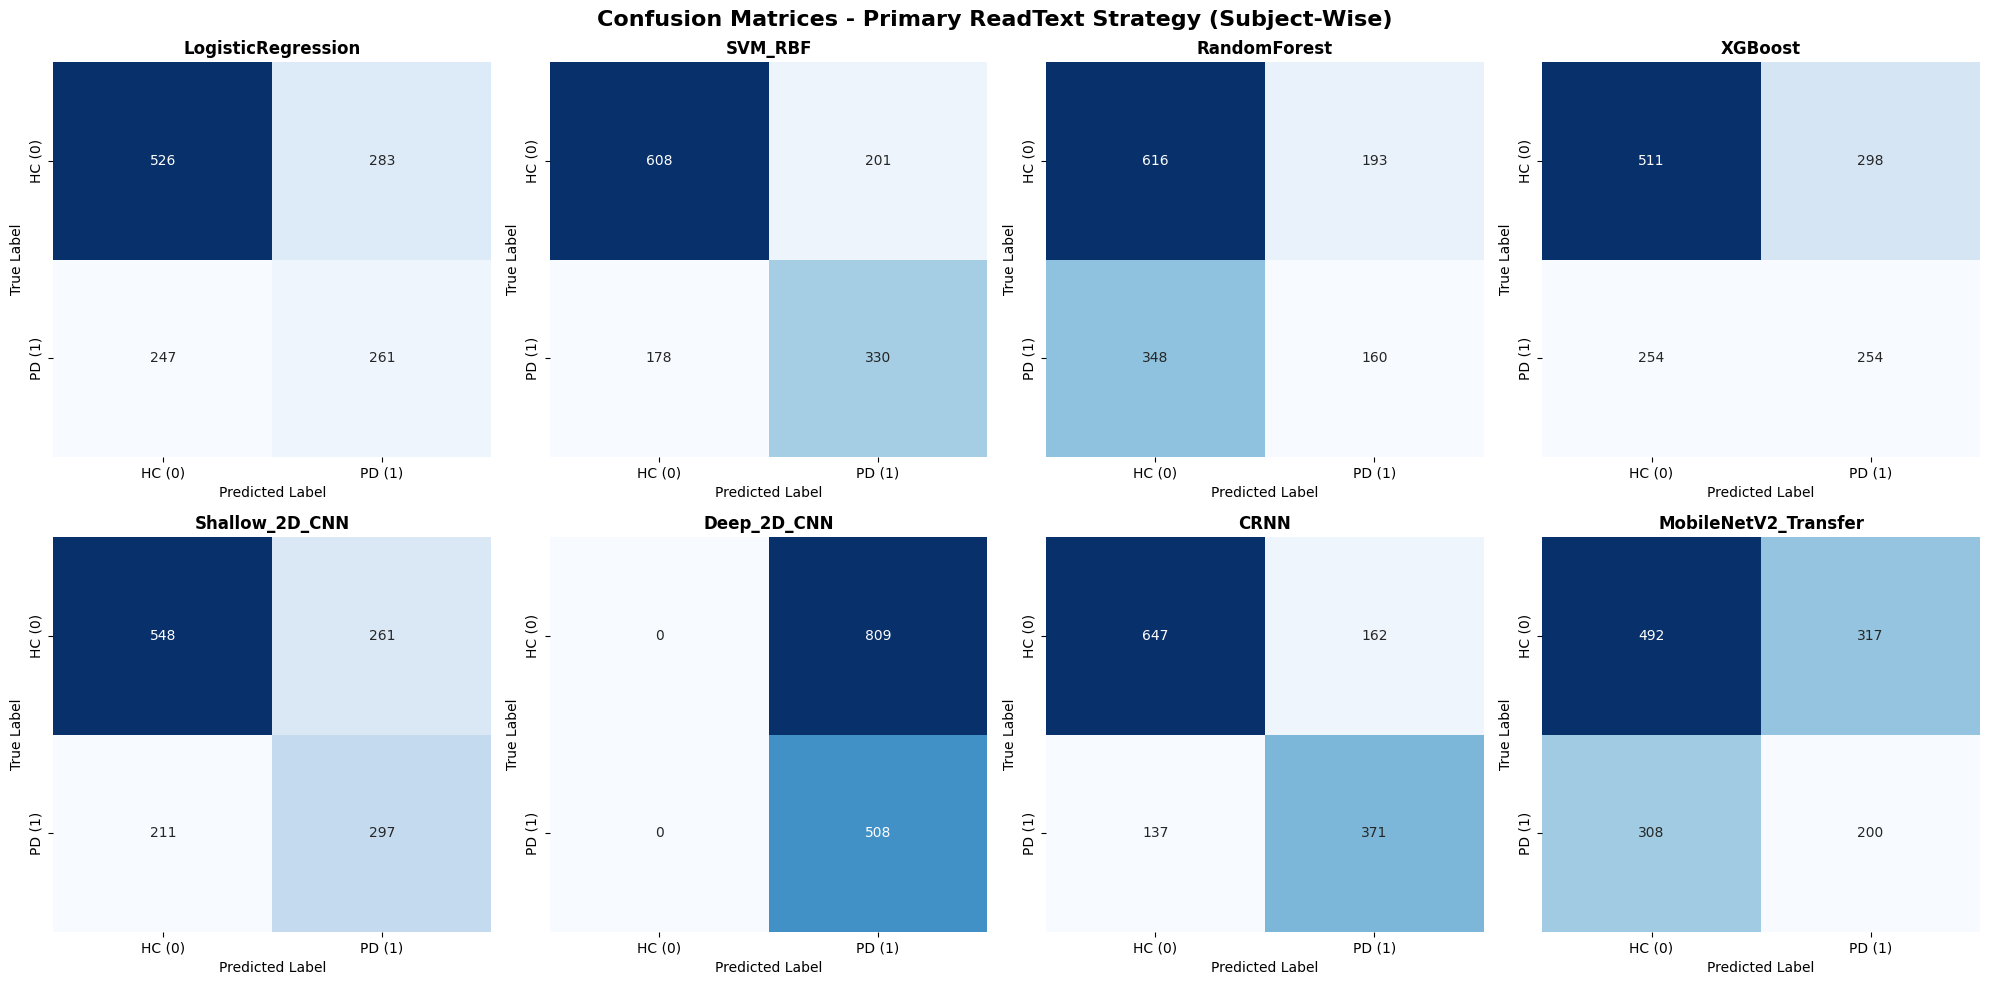

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

combined_tracker = {**classical_tracker, **deep_tracker}
combined_names_map = {**classical_names, **deep_names}

# Set up a 2x4 grid to accommodate all 8 models cleanly
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, (key, m_name) in enumerate(combined_names_map.items()):
    yt = np.array(combined_tracker[key]["y_true"])
    ypr = np.array(combined_tracker[key]["y_prob"])
    y_pred = np.where(ypr >= 0.5, 1, 0) if ypr.max() <= 1.0 else np.round(ypr)
    
    cm = confusion_matrix(yt, y_pred)
    ax = axes[idx]
    
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["HC (0)", "PD (1)"], yticklabels=["HC (0)", "PD (1)"])
    
    ax.set_title(f"{m_name}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

# Clean up any leftover empty subplots
for i in range(len(combined_names_map), len(axes)):
    fig.delaxes(axes[i])

plt.suptitle("Confusion Matrices - Primary ReadText Strategy (Subject-Wise)", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

##### 8.4 Model Bar-chat Metrics Comparison

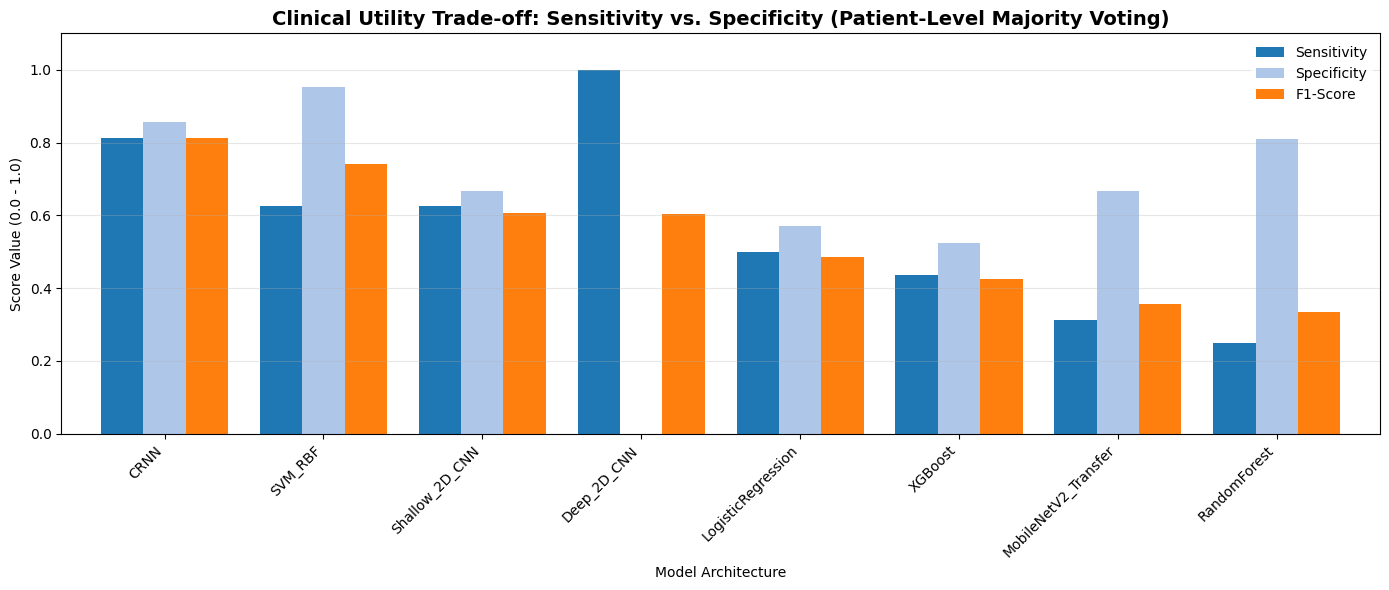

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Clean up and structure the real data we just calculated
df_plot = df_subject_metrics[[
    "Architecture Name", 
    "Sensitivity (Recall)", 
    "Specificity", 
    "F1-Score"
]].copy()

df_plot.columns = ["Model", "Sensitivity", "Specificity", "F1-Score"]
df_plot = df_plot.set_index("Model")

df_plot = df_plot.sort_values(by="F1-Score", ascending=False)

# 2. Generate your grouped bar chart dynamically
ax = df_plot.plot(kind="bar", figsize=(14, 6), width=0.8, color=['#1f77b4', '#aec7e8', '#ff7f0e'])
plt.title("Clinical Utility Trade-off: Sensitivity vs. Specificity (Patient-Level Majority Voting)", fontsize=14, fontweight='bold')
plt.ylabel("Score Value (0.0 - 1.0)")
plt.xlabel("Model Architecture")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.ylim(0, 1.1)
plt.legend(frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()
plt.show()

#### 9. Production Model Generation
Once evaluation is complete, the top-performing architecture is retrained one final time on the entire available dataset (all 37 subjects, no cross-validation holdouts). This final model, along with its complete preprocessing assets (such as scaling factors and clipping bounds), is serialized to disk using joblib or native Keras export functions to prepare for production deployment.

In [22]:
import joblib
import numpy as np

print("[STATUS] Preparing final production-grade serialization for winning models...")

joblib.dump(m2, "best_classical_svm_model.joblib")
joblib.dump(scaler, "classical_features_scaler.joblib")
print("[SUCCESS] Best Classical Model (SVM) and Scaler assets serialized.")

m7.save("best_deep_learning_crnn_model.keras")

normalization_bounds = {"t_min": float(t_min), "t_max": float(t_max)}
joblib.dump(normalization_bounds, "deep_learning_normalization_bounds.joblib")
print("[SUCCESS] Leaderboard Winner (CRNN) and Normalization Bounds serialized.")

print("\n[COMPLETE] Model and preprocessing assets successfully saved to disk.")

[STATUS] Preparing final production-grade serialization for winning models...
[SUCCESS] Best Classical Model (SVM) and Scaler assets serialized.
[SUCCESS] Leaderboard Winner (CRNN) and Normalization Bounds serialized.

[COMPLETE] Model and preprocessing assets successfully saved to disk.


#### 11. End-to-End Prediction Inference Engine
This standalone script defines a fully integrated prediction function. It ingests a raw .wav audio file from an unverified path, applies the same Voice Activity Detection (VAD) and temporal chunking steps used during training, runs the saved preprocessing pipeline, and averages the chunk-level probabilities to return a clean, unified patient-level prediction.

In [ ]:
import json
import joblib
import librosa
import numpy as np

def predict_from_file(file_path):
    """Loads a raw audio file, runs the extraction pipeline, and returns a subject-level prediction."""
    try:
        # Load the serialized production assets
        model = joblib.load("production_parkinsons_model.joblib")
        scaler = joblib.load("production_scaler.joblib")
        lo_b, hi_b = joblib.load("production_iqr_bounds.joblib")
        
        # Load and preprocess the target audio file
        y, sr = librosa.load(file_path, sr=None)
        v_sig = apply_voice_activity_detection(y, sr)
        chunks = generate_temporal_chunks(v_sig, sr)
        
        if len(chunks) == 0:
            return {
                "status": "error",
                "message": "Audio file does not contain sufficient voiced speech components for evaluation."
            }
            
        # Extract features from each valid chunk
        chunk_features = [extract_handcrafted_metrics(c, sr) for c in chunks]
        X_raw = np.array(chunk_features)
        
        # Apply the saved preprocessing transformations
        X_clipped = np.clip(X_raw, lo_b, hi_b)
        X_scaled = scaler.transform(X_clipped)
        
        # Aggregate the chunk-level probabilities into a single subject-level prediction
        chunk_probabilities = model.predict_proba(X_scaled)[:, 1]
        mean_probability = float(np.mean(chunk_probabilities))
        
        # Map the average probability to a final clinical label
        binary_prediction = 1 if mean_probability >= 0.5 else 0
        clinical_label = "Parkinson's Disease" if binary_prediction == 1 else "Healthy Control"
        confidence_score = mean_probability if binary_prediction == 1 else (1.0 - mean_probability)
        
        return {
            "status": "success",
            "binary_prediction": binary_prediction,
            "clinical_label": clinical_label,
            "confidence_percentage": round(confidence_score * 100, 2)
        }
    except Exception as e:
        return {"status": "error", "message": f"Inference pipeline failed. Details: {str(e)}"}

print("[STATUS] End-to-end local inference engine successfully initialized.")

[STATUS] End-to-end local inference engine successfully initialized.


In [23]:
import os
from IPython.display import FileLink, display

print("[STATUS] Generating local download links for all 4 production assets...")

required_files = [
    "best_classical_svm_model.joblib",
    "classical_features_scaler.joblib",
    "best_deep_learning_crnn_model.keras",
    "deep_learning_normalization_bounds.joblib"
]

for file_name in required_files:
    if os.path.exists(file_name):
        print(f" -> Found: {file_name}")
        display(FileLink(file_name, result_html_prefix=f"Click here to download: "))
    else:
        print(f" [ERROR] Missing asset: {file_name}. Please ensure the previous saving cell ran completely.")

print("\n[COMPLETE] Click the links above to save all 4 deployment assets locally.")

[STATUS] Generating local download links for all 4 production assets...
 -> Found: best_classical_svm_model.joblib


/kaggle/working/best_classical_svm_model.joblib

 -> Found: classical_features_scaler.joblib


/kaggle/working/classical_features_scaler.joblib

 -> Found: best_deep_learning_crnn_model.keras


/kaggle/working/best_deep_learning_crnn_model.keras

 -> Found: deep_learning_normalization_bounds.joblib


/kaggle/working/deep_learning_normalization_bounds.joblib


[COMPLETE] Click the links above to save all 4 deployment assets locally.
